<a href="https://colab.research.google.com/github/ManuJLV/PracticasIA/blob/main/Taller_clustering_y_vinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
uploaded = files.upload()

Saving vinosNorm.csv to vinosNorm.csv


In [ ]:
df = pd.read_csv(io.StringIO(uploaded['vinosNorm.csv'].decode('utf-8')))
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.705263,0.970356,0.582888,0.510309,0.271739,0.241379,0.056962,0.735849,0.205047,0.547782,0.130081,0.172161,0.329529
174,0.623684,0.626482,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.315457,0.513652,0.178862,0.106227,0.336662
175,0.589474,0.699605,0.481283,0.484536,0.543478,0.210345,0.073840,0.566038,0.296530,0.761092,0.089431,0.106227,0.397290
176,0.563158,0.365613,0.540107,0.484536,0.543478,0.231034,0.071730,0.754717,0.331230,0.684300,0.097561,0.128205,0.400856


In [ ]:
#Calculo de K
#Al observar como varía la suma de los errores cuadráticos (o inercia) a medida que se aumenta el número de cústeres,
#la inercia disminuye, lo que indica que los puntos de datos están más cerca de sus respectivos centroides
#La clave será identificar el "codo" en la curva. Ese punto donde se empieza a reducir la inercia donde la curva empieza a suavisarce o aplanarse
#A medida que se aumenta el número de clústeres.
#Inercia = SSE = WCSS (Within-Cluster Sum of squares)

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300)
    #Kmeans++ busca inicializar un centroide aleatorio y luego genera uno alejado del primero
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

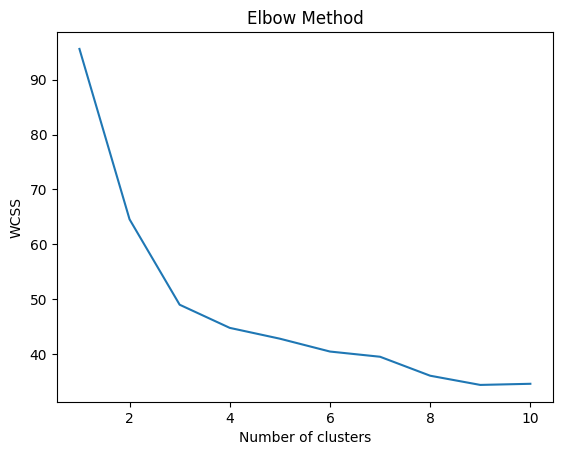

In [ ]:
#Graficar lo que quedó en wcc
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()
#

In [ ]:
#Aplicar ahora -means
#crear primero el modelo
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300)
#entrenar
kmeans.fit(df)

KMeans(n_clusters=3)

In [ ]:
#Revisar las etiquetas que quedaron y guardarlo en una variable
etiquetas = kmeans.labels_
print(etiquetas)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 0 2 2 2 2 1 2 2 2 2 1 2 1
 1 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 1 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
#Dado que se tienen 13 características, no es posible hacer un gráfico que las represente a todas
#Por lo que toca aplicar una técnica que se llama Análisis de componentes principales o PCA
#Cada componente es una combinacion lineal de las variables originales. Esto significa que cada dato del conjunto
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)
vinos_pca = pca.fit_transform(df)

In [ ]:
#Crear un nuevo dataframe a partir de los valores de vinos_pca
df_pca = pd.DataFrame(data=vinos_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = etiquetas
df_pca

,PC1,PC2,cluster
0,0.706336,0.253193,1
1,0.484977,0.008823,1
2,0.521172,0.189187,1
3,0.821644,0.580906,1
4,0.202546,0.059467,1
...,...,...,...
173,-0.739510,0.471901,0
174,-0.581781,0.348366,0
175,-0.626313,0.546857,0
176,-0.572991,0.425516,0


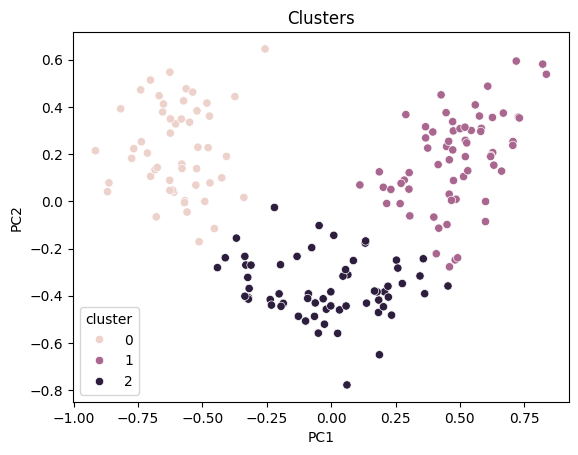

In [ ]:
#Visualización de los clusters
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca)
plt.title('Clusters')
plt.show()


In [ ]:
#Suma de errores, calcular la inercia
inercia = kmeans.inertia_
print(inercia)

48.98541496004466


In [ ]:
#Calcular el indice de silueta para nuestro ejercicio
silhouette = silhouette_score(df, etiquetas)
print(f'"Silhouette Score: ", {silhouette:.2f}')

"Silhouette Score: ", 0.30
